pre-determined noise pattern in a video as verifier for video not being AI generated .

generating and maintaining the same noise pattern across frames is EXTREMELY hard for current AI systems.
viewers can verify that it is the same noise pattern by pausing the video then check for match with the published text file of RGB values.

note: level of confidence increases with inscreasing size of noise pattern and amount of natural changes(in lighting & view) of the pattern-carrying object in the video

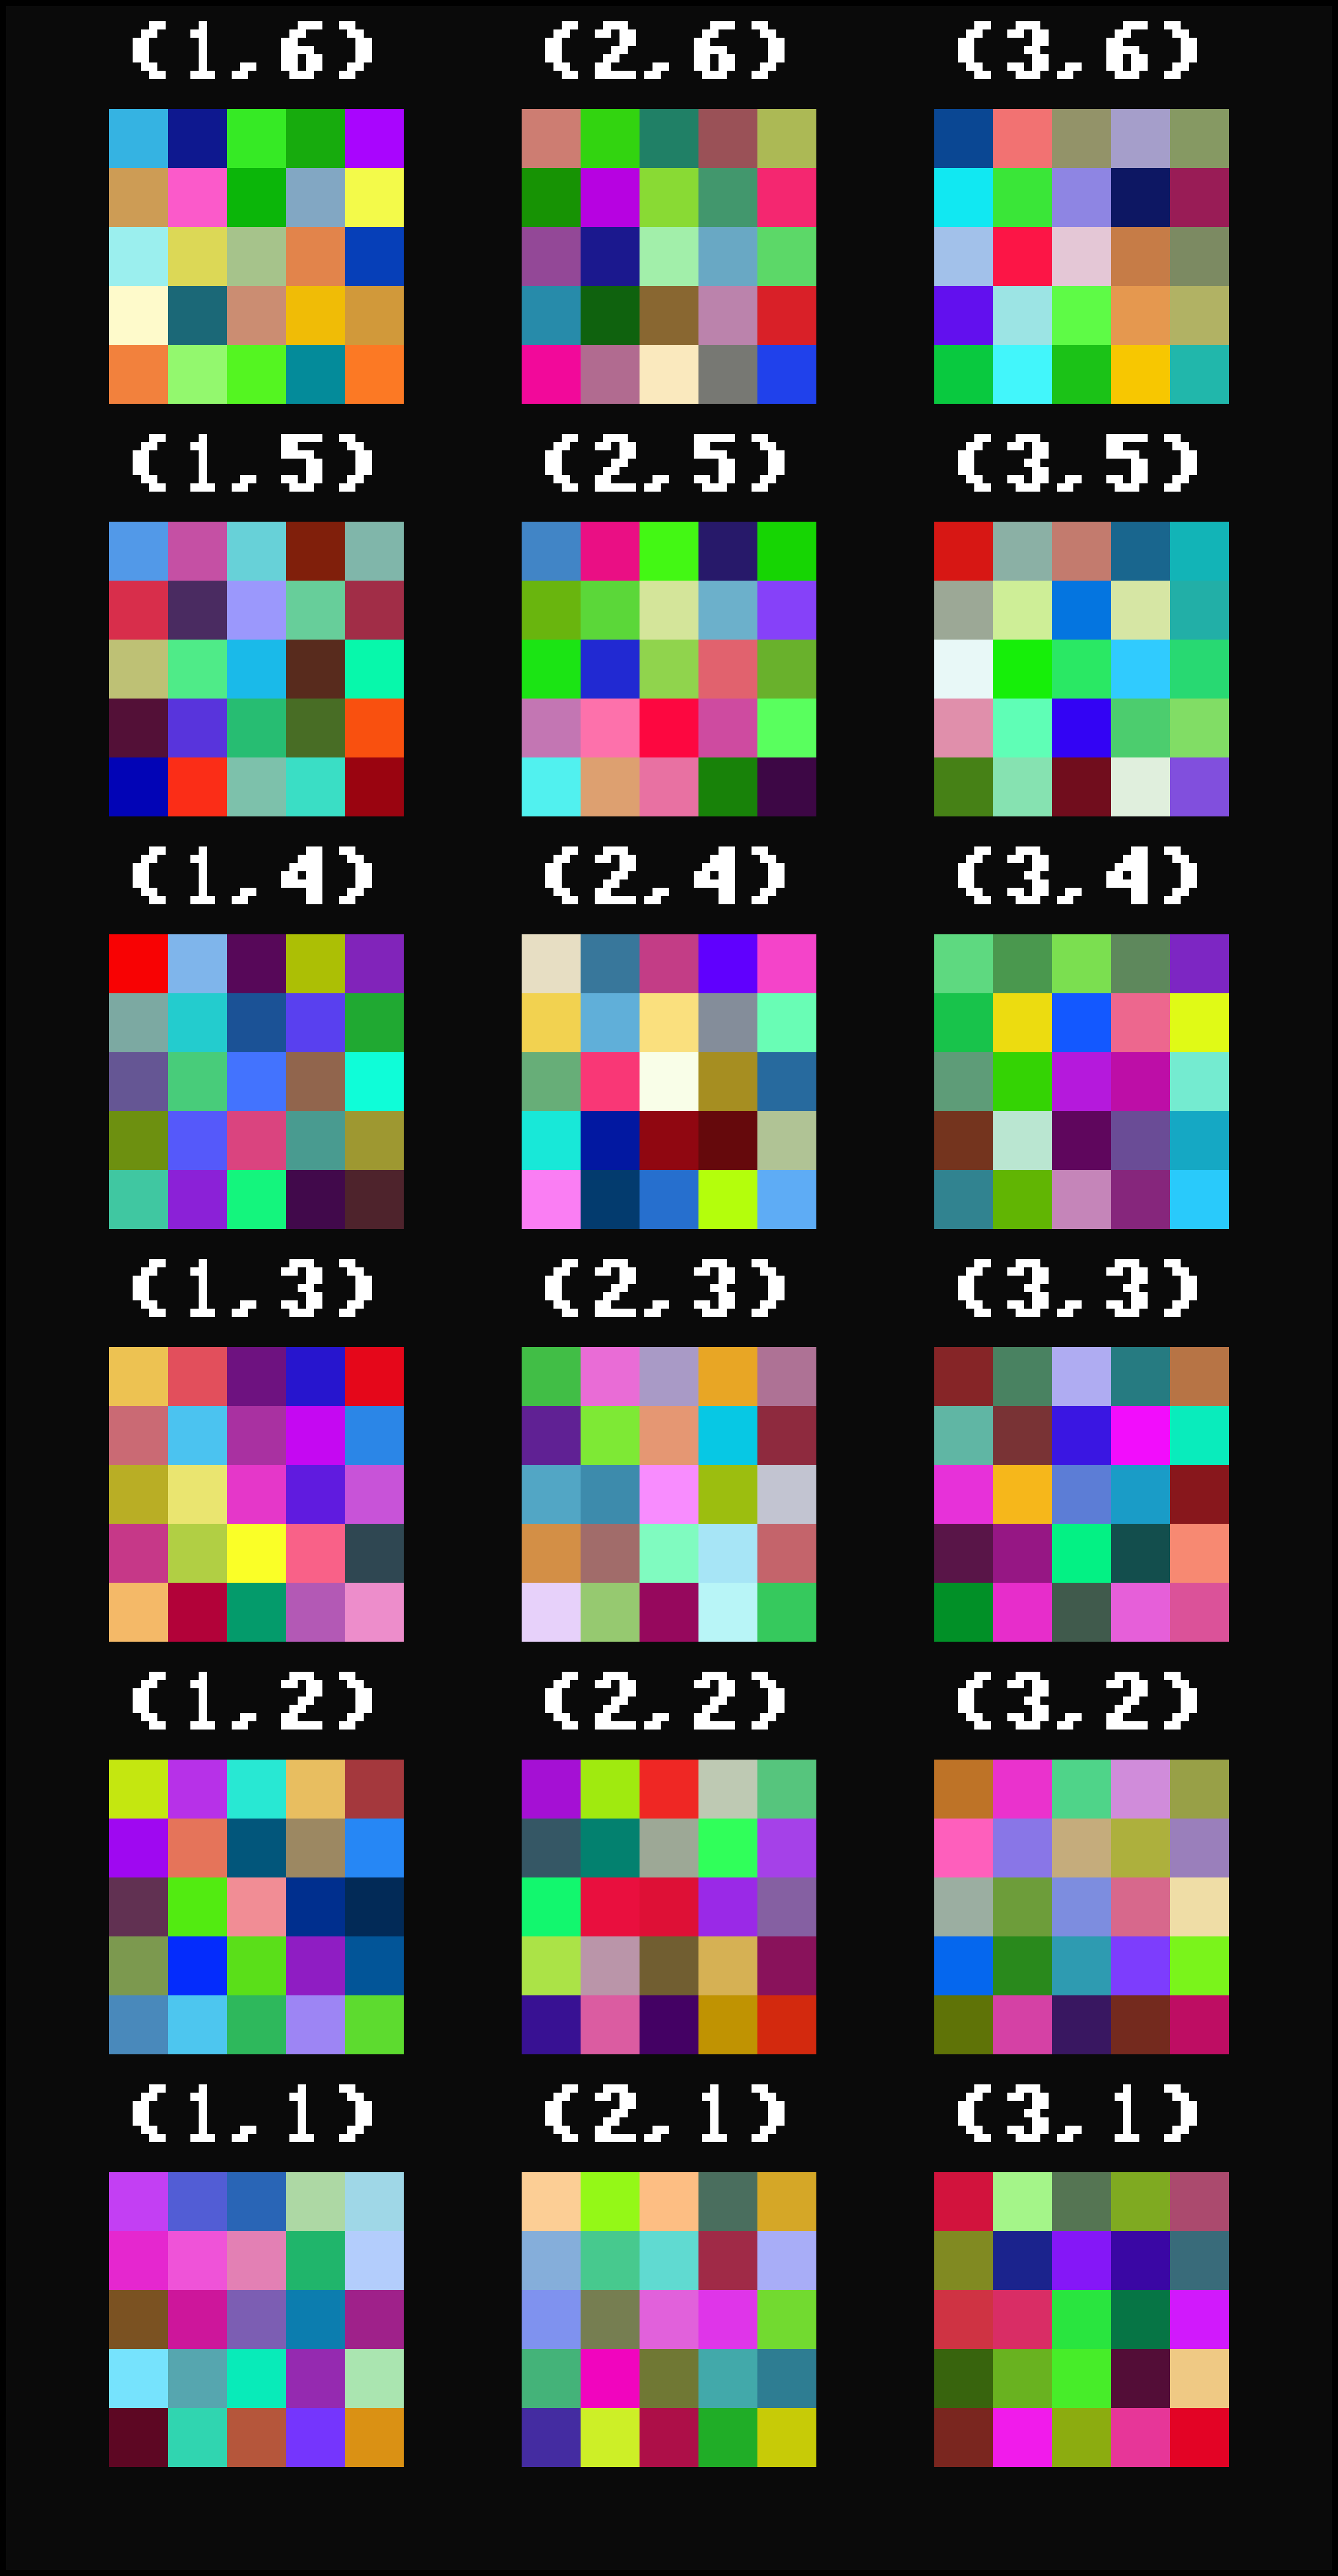

Image: random_pixel_blocks.png (2250 × 4350 px)
Data : random_pixel_blocks.txt
Block size: 500px | Gap: 200px | Label scale: 14


In [54]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

# ===================== SETTINGS =====================
NUM_BLOCKS_X, NUM_BLOCKS_Y = 3, 6
PIXELS_PER_BLOCK = 5
RESOLUTION = 100          # rendered pixels per noise pixel

GAP_RATIO = 0.40         # gap / block size
MARGIN_RATIO = 0.35      # margin / block size
LABEL_RATIO = 0.70       # label scale / gap

OUTPUT_IMAGE = "random_pixel_blocks.png"
OUTPUT_TEXT  = "random_pixel_blocks.txt"
SEED = None              # None = new pattern each run

# ===================== BITMAP FONT ===================
# No external fonts required.
GLYPHS = {
    "0": [
        "01110",
        "11011",
        "11011",
        "11011",
        "11011",
        "11011",
        "01110",
    ],
    "1": [
        "00100",
        "01100",
        "00100",
        "00100",
        "00100",
        "00100",
        "01110",
    ],
    "2": [
        "01110",
        "11011",
        "00011",
        "00110",
        "01100",
        "11000",
        "11111",
    ],
    "3": [
        "01110",
        "11011",
        "00011",
        "00110",
        "00011",
        "11011",
        "01110",
    ],
    "4": [
        "00011",
        "00111",
        "01111",
        "11011",
        "11111",
        "00011",
        "00011",
    ],
    "5": [
        "11111",
        "11000",
        "11110",
        "00011",
        "00011",
        "11011",
        "01110",
    ],
    "6": [
        "00111",
        "01100",
        "11000",
        "11110",
        "11011",
        "11011",
        "01110",
    ],
    "7": [
        "11111",
        "00011",
        "00110",
        "01100",
        "01100",
        "01100",
        "01100",
    ],
    "8": [
        "01110",
        "11011",
        "11011",
        "01110",
        "11011",
        "11011",
        "01110",
    ],
    "9": [
        "01110",
        "11011",
        "11011",
        "01111",
        "00011",
        "00110",
        "11100",
    ],

    "(": [
        "00110",
        "01100",
        "11000",
        "11000",
        "11000",
        "01100",
        "00110",
    ],

    ")": [
        "01100",
        "00110",
        "00011",
        "00011",
        "00011",
        "00110",
        "01100",
    ],

    ",": [
        "00000",
        "00000",
        "00000",
        "00000",
        "00000",
        "01100",
        "11000",
    ],
}

def draw_label(draw, text, x, y, scale, fill=(255, 255, 255)):
    """Draw bitmap text with its top-left corner at (x,y)."""
    spacing = scale
    cursor_x = x

    for char in text:
        glyph = GLYPHS[char]
        glyph_width = len(glyph[0])

        for gy, row in enumerate(glyph):
            for gx, value in enumerate(row):
                if value == "1":
                    draw.rectangle(
                        (
                            cursor_x + gx * scale,
                            y + gy * scale,
                            cursor_x + (gx + 1) * scale - 1,
                            y + (gy + 1) * scale - 1,
                        ),
                        fill=fill,
                    )

        cursor_x += glyph_width * scale + spacing

    return cursor_x - x


# ===================== DATA =========================
rng = np.random.default_rng(SEED)
rgb = rng.integers(
    256,
    size=(NUM_BLOCKS_Y, NUM_BLOCKS_X,
          PIXELS_PER_BLOCK, PIXELS_PER_BLOCK, 3),
    dtype=np.uint8,
)

# ===================== SCALE ========================
block_size = PIXELS_PER_BLOCK * RESOLUTION
gap = round(block_size * GAP_RATIO)
margin = round(block_size * MARGIN_RATIO)

# Label scale grows directly with the gap.
label_scale = max(1, round(gap * LABEL_RATIO / 10))

width  = 2 * margin + NUM_BLOCKS_X * block_size + (NUM_BLOCKS_X - 1) * gap
height = 2 * margin + NUM_BLOCKS_Y * block_size + (NUM_BLOCKS_Y - 1) * gap

# ===================== IMAGE ========================
canvas = Image.new("RGB", (width, height), (10, 10, 10))
draw = ImageDraw.Draw(canvas)

for by in range(NUM_BLOCKS_Y):
    for bx in range(NUM_BLOCKS_X):
        x, y = bx + 1, by + 1
        display_row = NUM_BLOCKS_Y - 1 - by

        left = margin + bx * (block_size + gap)
        top = margin + display_row * (block_size + gap)

        # Cartesian y increases upward.
        block = Image.fromarray(np.flipud(rgb[by, bx]), "RGB").resize(
            (block_size, block_size),
            Image.Resampling.NEAREST,
        )
        canvas.paste(block, (left, top))

        # ================= COORDINATE LABEL ==========
        label = f"({x},{y})"

        # Calculate bitmap label dimensions.
        label_width = draw_label(
            ImageDraw.Draw(Image.new("RGB", (1, 1))),
            label, 0, 0, label_scale
        )
        label_height = 7 * label_scale

        # Center label in gap above block.
        tx = left + (block_size - label_width) / 2
        ty = top - gap + (gap - label_height) / 2

        draw_label(draw, label, int(tx), int(ty), label_scale)

canvas.save(OUTPUT_IMAGE)

# ===================== TEXT FILE ====================
def pixel_record(px, py, r, g, b):
    return f"(x={px:02d},y={py:02d})=RGB({r:03d},{g:03d},{b:03d})"

record_width = len(pixel_record(10, 10, 255, 255, 255))
divider = "-" * (PIXELS_PER_BLOCK * record_width + (PIXELS_PER_BLOCK - 1) * 3)

with open(OUTPUT_TEXT, "w", encoding="utf-8") as f:
    f.write(
        "RANDOM RGB PIXEL DATA\n"
        "Coordinate system: Cartesian\n"
        "Block (1,1) = bottom-left; Pixel (1,1) = bottom-left\n"
        "x increases left -> right; y increases bottom -> top\n\n"
    )

    for by in range(NUM_BLOCKS_Y):
        for bx in range(NUM_BLOCKS_X):
            f.write(f"BLOCK (x={bx+1}, y={by+1})\n{divider}\n")

            for py in range(PIXELS_PER_BLOCK):
                row = []
                for px in range(PIXELS_PER_BLOCK):
                    r, g, b = map(int, rgb[by, bx, py, px])
                    row.append(pixel_record(px+1, py+1, r, g, b))
                f.write(" | ".join(row) + "\n")

            f.write("\n")

# ===================== DISPLAY ======================
fig, ax = plt.subplots(
    figsize=(width / 100, height / 100),
    dpi=100,
    facecolor="black",
)

ax.imshow(canvas)
ax.axis("off")
fig.subplots_adjust(0, 0, 1, 1)
plt.show()

print(f"Image: {OUTPUT_IMAGE} ({width} × {height} px)")
print(f"Data : {OUTPUT_TEXT}")
print(f"Block size: {block_size}px | Gap: {gap}px | Label scale: {label_scale}")

In [ ]:
def show_pixel(rgb_string, size=3):
    """
    Display a single RGB pixel.

    """

    try:
        r, g, b = map(int, rgb_string.replace(" ", "").split(","))
    except ValueError:
        raise ValueError(
            'RGB must be provided as a string like "084,004,033".'
        )

    if not all(0 <= value <= 255 for value in (r, g, b)):
        raise ValueError("RGB values must be between 0 and 255.")

    pixel = np.array([[[r, g, b]]], dtype=np.uint8)

    plt.figure(figsize=(size, size))
    plt.imshow(pixel)
    plt.axis("off")
    plt.show()

    print(f"RGB = ({r}, {g}, {b})")

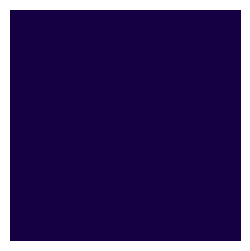

RGB = (21, 0, 68)


In [50]:
show_pixel("021,000,068")